# Latent-rank selection on a linear Gaussian oracle

`select_latent_rank` scores truncated-SVD ranks of **frozen**
encodings. On a rank-3 AR(1) embedded in $\mathbb{R}^{8}$,
the helper recovers `selected_rank == 3` when each criterion
is paired with a matching excitation: the variational
approach for Markov processes (VAMP-2) score and
`stability_penalized` on a process-noise-driven series,
`resdmd_elbow` on the noiseless embedding. Swapping those
series selects rank 1 or 2 instead.

**Honesty.** This is not Ray Tune / AutoML for encoder
`latent_dim`. It does not train a model per candidate.
`koopman_graph.tuning` remains caller-owned HPO.
Finite-dictionary residual dynamic mode decomposition
(ResDMD) residuals are not a certified
infinite-dimensional bound. This notebook does **not**
download METR-LA.


## Setup

Package version, the VAMP-2 plateau relative gap, and a
rank-3 diagonal AR(1) with an orthonormal embedding into
ambient 8. Process noise, when present, is isotropic on
the three latent coordinates (not an exogenous input).


In [1]:
from __future__ import annotations

import os
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch

import koopman_graph
from koopman_graph.identification.invariance import SINGULAR_VALUE_REL_CUTOFF
from koopman_graph.identification.rank import (
    VAMP2_PLATEAU_RELATIVE,
    select_latent_rank,
)

TRUE_RANK = 3
AMBIENT = 8
CANDIDATES = (1, 2, 3, 4, 5, 6)

print("koopman_graph", koopman_graph.__version__)
print("VAMP2_PLATEAU_RELATIVE", VAMP2_PLATEAU_RELATIVE)
print("SINGULAR_VALUE_REL_CUTOFF", SINGULAR_VALUE_REL_CUTOFF)


def rank3_ambient_encodings(
    *, num_times: int, seed: int, process_noise: float
) -> torch.Tensor:
    generator = torch.Generator(device="cpu").manual_seed(seed)
    true_k = torch.diag(torch.tensor([0.95, 0.90, 0.85], dtype=torch.float64))
    embedding, _ = torch.linalg.qr(
        torch.randn(AMBIENT, TRUE_RANK, dtype=torch.float64, generator=generator)
    )
    state = torch.randn(TRUE_RANK, dtype=torch.float64, generator=generator)
    frames = [state]
    for _ in range(num_times - 1):
        state = state @ true_k.T
        if process_noise > 0.0:
            state = state + process_noise * torch.randn(
                TRUE_RANK, dtype=torch.float64, generator=generator
            )
        frames.append(state)
    return torch.stack(frames, dim=0) @ embedding.T


koopman_graph 0.15.0
VAMP2_PLATEAU_RELATIVE 0.001
SINGULAR_VALUE_REL_CUTOFF 1e-08


## Motivation and background

Choosing how many coordinates to keep after a frozen
encoder is a dictionary-rank problem, not a search over
`GraphKoopmanModel.latent_dim`. The usual alternatives are
to inspect singular values of the encoding cloud by hand,
or to train one model per width with
`example_lr_latent_dim_space` and Ray Tune.

VAMP-2 (Wu and Noé, 2020) scores a time-lagged linear map
on a feature dictionary: larger
$\|C_{00}^{-1/2} C_{01} C_{11}^{-1/2}\|_F^2$ is better.
The in-tree score is mean-free: lag features are
column-mean-centered before those covariances are formed.
It is not the optional deeptime (`[msm]`) cross-check,
which includes a constant singular value. Here the
dictionary is a truncated-SVD projection of
frozen encodings. `criterion="vamp2"` maximizes that
score, then keeps the smallest rank within relative gap
`VAMP2_PLATEAU_RELATIVE` ($10^{-3}$) of the peak.

`criterion="resdmd_elbow"` minimizes the maximum
finite-dictionary ResDMD residual of Colbrook and
Townsend (2023/2024); ties go to the smallest rank.
`criterion="stability_penalized"` minimizes held-out
ambient one-step mean squared error (MSE) plus
`stability_penalty * max(0, ρ(K) - 1)`. Without
`validation_z`, the last half of the series is the
hold-out (requires $T \ge 4$).


## Minimal example

`criterion="vamp2"` on the driven series
(`process_noise=0.25`). Higher VAMP-2 is better; the
plateau rule can still prefer a smaller rank when scores
flatten.


In [2]:
driven = rank3_ambient_encodings(num_times=48, seed=0, process_noise=0.25)
vamp = select_latent_rank(driven, CANDIDATES, criterion="vamp2")
print("selected_rank", vamp.selected_rank)
print("numerical_rank", vamp.numerical_rank)
print("candidates scored", vamp.candidates)
print("rejected", vamp.rejected_alternatives)
print("vamp2 scores (higher is better)", vamp.scores)
print("n_samples", vamp.n_samples)
assert vamp.selected_rank == TRUE_RANK
assert vamp.numerical_rank == TRUE_RANK


selected_rank 3
numerical_rank 3
candidates scored (1, 2, 3)
rejected ('4', '5', '6')
vamp2 scores (higher is better) (0.5999314398242473, 1.054344974375685, 1.411381108538763)
n_samples 47


## Progressive deep dive

Process noise keeps all three AR(1) modes excited, which
VAMP-2 and the stability score need. The same noise
inflates extra-mode ResDMD residuals, so `resdmd_elbow`
is scored on the noiseless embedding, where the rank-3
map is exact and the max residual falls to 0.


In [3]:
quiet = rank3_ambient_encodings(num_times=48, seed=0, process_noise=0.0)
elbow = select_latent_rank(quiet, CANDIDATES, criterion="resdmd_elbow")
stable = select_latent_rank(driven, CANDIDATES, criterion="stability_penalized")
print("resdmd_elbow selected", elbow.selected_rank)
print("resdmd_elbow residuals (lower is better)", elbow.scores)
print("stability_penalized selected", stable.selected_rank)
print("stability_penalized scores (lower is better)", stable.scores)
print("stability n_samples", stable.n_samples)
assert elbow.selected_rank == TRUE_RANK
assert stable.selected_rank == TRUE_RANK
assert stable.n_samples == 23


resdmd_elbow selected 3
resdmd_elbow residuals (lower is better) (0.0005696588618133979, 6.885426126343342e-05, 0.0)
stability_penalized selected 3
stability_penalized scores (lower is better) (0.035462012198183845, 0.031518218821961805, 0.029604166342325874)
stability n_samples 23


Without `select_latent_rank`, the same truncated-SVD
cutoff (`SINGULAR_VALUE_REL_CUTOFF` times the leading
singular value) already shows that ranks 4–6 sit above
the numerical rank of the cloud. The helper still has to
score 1, 2, and 3.


In [4]:
rows = driven.reshape(-1, driven.shape[-1])
_, singular_values, _ = torch.linalg.svd(rows, full_matrices=False)
peak = float(singular_values[0])
cutoff = SINGULAR_VALUE_REL_CUTOFF * peak
manual_rank = int((singular_values > cutoff).sum().item())
print("leading singular values", [round(float(s), 6) for s in singular_values[:6]])
print("manual numerical rank", manual_rank)
print("helper numerical_rank", vamp.numerical_rank)
assert manual_rank == vamp.numerical_rank == TRUE_RANK


leading singular values [4.21588, 2.535549, 1.72406, 0.0, 0.0, 0.0]
manual numerical rank 3
helper numerical_rank 3


Swapping the series is a negative control, not a second
oracle success. `resdmd_elbow` on the driven cloud and
`vamp2` on the noiseless cloud do not recover rank 3.


In [5]:
elbow_driven = select_latent_rank(driven, CANDIDATES, criterion="resdmd_elbow")
vamp_quiet = select_latent_rank(quiet, CANDIDATES, criterion="vamp2")
print("resdmd_elbow on driven", elbow_driven.selected_rank, elbow_driven.scores)
print("vamp2 on noiseless", vamp_quiet.selected_rank, vamp_quiet.scores)
assert elbow_driven.selected_rank == 1
assert vamp_quiet.selected_rank == 2


resdmd_elbow on driven 1 (0.46120521034851536, 0.7564452840223927, 0.8067968093510759)
vamp2 on noiseless 2 (0.9996073261347352, 1.742493502507564, 1.743306158740795)


## Results

Figure 1 plots scores against scored ranks for the three
**matched** pairings. VAMP-2 rises through rank 3 (about
0.60, 1.05, 1.41); the peak is isolated, so the plateau
rule still selects 3. On the noiseless cloud the ResDMD
residual falls to 0 at rank 3. Stability-penalized
held-out MSE decreases slightly (about 0.035, 0.032,
0.030) with 23 lag pairs from the last half of $T=48$.
Candidates 4, 5, and 6 are rejected as above the
numerical SVD rank; they are never scored.

The swapped-series cell shows the complementary failure:
driven `resdmd_elbow` selects 1 (residuals rise with
rank) and noiseless `vamp2` selects 2 (ranks 2 and 3 lie
on the plateau). Rank-3 recovery is therefore a property
of the pairing, not of the oracle alone.


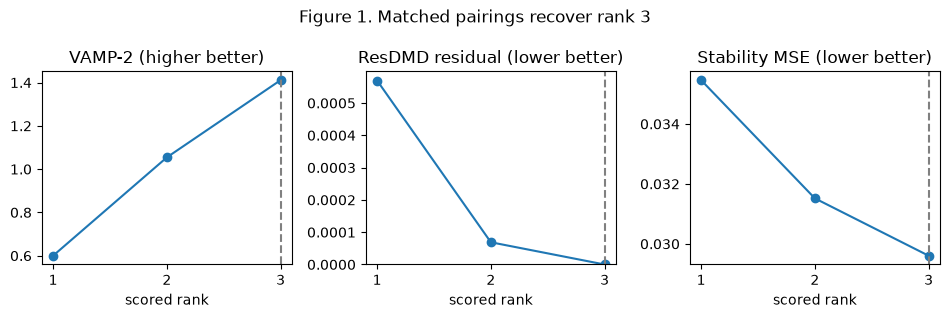

rejected (above numerical SVD rank) ('4', '5', '6')


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2))
panels = (
    (axes[0], vamp.candidates, vamp.scores, vamp.selected_rank, "VAMP-2 (higher better)"),
    (axes[1], elbow.candidates, elbow.scores, elbow.selected_rank, "ResDMD residual (lower better)"),
    (axes[2], stable.candidates, stable.scores, stable.selected_rank, "Stability MSE (lower better)"),
)
for ax, ranks, scores, chosen, title in panels:
    ax.plot(ranks, scores, marker="o")
    ax.axvline(chosen, color="0.5", linestyle="--")
    ax.set_xticks(list(ranks))
    ax.set_xlabel("scored rank")
    ax.set_title(title)
axes[1].set_ylim(bottom=0.0)
fig.suptitle("Figure 1. Matched pairings recover rank 3")
fig.tight_layout()
plt.show()

print("rejected (above numerical SVD rank)", vamp.rejected_alternatives)
assert vamp.rejected_alternatives == ("4", "5", "6")


## Interpretation / discussion

The selected integer is a dictionary rank of the frozen
cloud. It is not a recommendation that encoder
`latent_dim` equal 3, and it is not Ray Tune.
`example_lr_latent_dim_space` remains a caller-owned
smoke scaffold; see the [tuning API](../docs/source/api.rst).

The three criteria answer different questions (kinetic
variance, finite-dictionary residual, held-out
reconstruction plus a spectral-radius penalty). They
agree on this linear Gaussian toy only when excitation
matches the score. A nonlinear encoder, a short series,
or a weakly excited mode can move the numerical SVD rank
or the VAMP-2 plateau.

`resdmd_elbow` uses a finite dictionary. It is not a
certified Colbrook–Townsend residual bound on the
infinite-dimensional Koopman operator.


## Takeaways

- **When to use.** Score a candidate grid on **frozen**
  encodings when the cloud is approximately low-rank and
  you want a documented integer dictionary rank.
- **When not to use.** Not Ray Tune for `latent_dim`.
  Do not train one encoder per candidate; do not treat
  `selected_rank` as a recommended encoder width.
- **Pairing gotcha.** On this rank-3-in-ambient-8
  oracle, VAMP-2 / `stability_penalized` need process
  noise; `resdmd_elbow` needs the noiseless embedding.
  Swapping those series selects 1 or 2, not 3.
- **Selection rules.** VAMP-2 is maximized, then the
  smallest rank within $10^{-3}$ of the peak is kept.
  ResDMD residuals and stability scores are minimized
  (ties → smallest rank).
- **Other gotchas.** Candidates above the numerical SVD
  rank are rejected without scoring.
  `stability_penalized` without `validation_z` uses the
  last half of $T$ as hold-out. Finite-dictionary
  ResDMD is not a certified residual bound.


## Further reading

- Sphinx: [identification](../docs/source/identification.rst),
  [faq](../docs/source/faq.rst),
  [api](../docs/source/api.rst) (`select_latent_rank`,
  `koopman_graph.tuning`),
  [limitations](../docs/source/limitations.rst)
- Wu and Noé (2020), *J. Nonlinear Sci.*
  ([doi:10.1007/s00332-019-09567-y](https://doi.org/10.1007/s00332-019-09567-y);
  `Wu2020VAMP`)
- Colbrook and Townsend (2023/2024), *Comm. Pure Appl. Math.*
  ([doi:10.1002/cpa.22125](https://doi.org/10.1002/cpa.22125);
  `ColbrookTownsend2023ResDMD`)
- Hoffmann et al. (2021/2022), *Mach. Learn.: Sci. Technol.*
  ([doi:10.1088/2632-2153/ac3de0](https://doi.org/10.1088/2632-2153/ac3de0);
  `deeptime2021`; optional VAMP-2 cross-check, not a runtime
  requirement)
- Example [48_identification_invariance.ipynb](48_identification_invariance.ipynb)
- Example [40_resdmd_pseudospectra.ipynb](40_resdmd_pseudospectra.ipynb)
  (resolvent-norm grid; not this rank helper)
